In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks, Z_from_DRT
from redoxed.dc import PolarisationData
from redoxed.impedance.drt_solver import DRT_rr_solver


from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

# Z-HIT
from pyimpspec import perform_zhit, ZHITResult
# circuit fit
from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)



%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


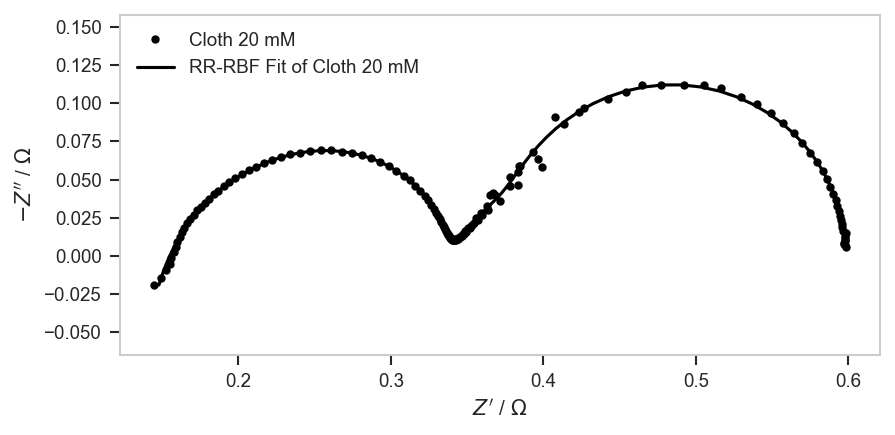

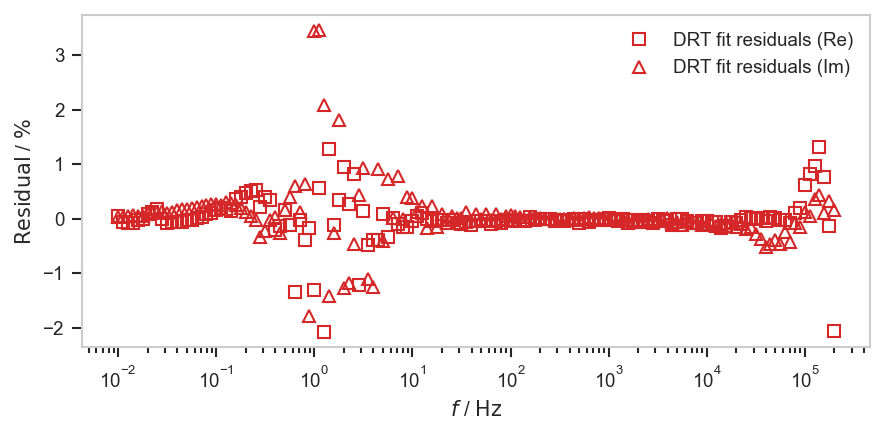

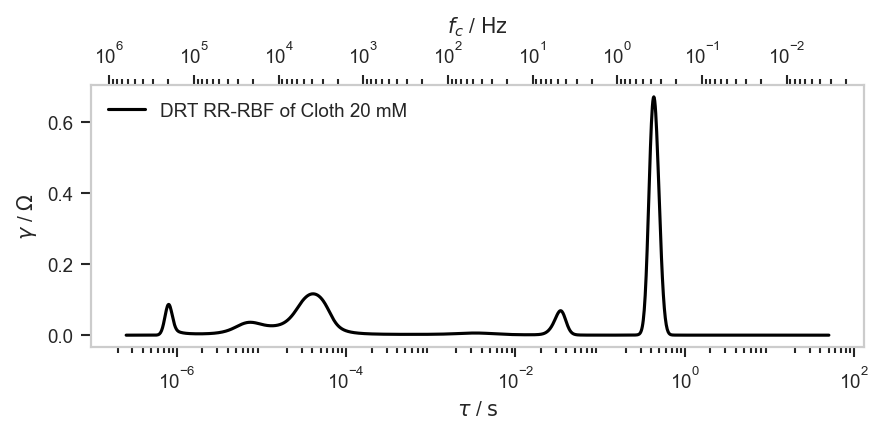

In [15]:
# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.06.15 FB2_FCN_KCl_E620K_1186HCB\17_replelec_C04.mpr"
label = "Cloth 20 mM"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
EISData_object = ECData_object.to_EISData()
EISData_object.crop_frequency(0.01, 2e5)
# EISData_object.crop_frequency(0.01, 1e4)
EISData_object.label = label
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }


#########################
###### DRT fitting ######
#########################

# f = EISData_object.f
# # Number of decades to add on each side
# extra_decades = 1.0  # e.g. 1 decade below and above
# # Points per decade
# points_per_decade = 20
# # Assume f is your original log-spaced frequency array
# f_min = np.min(f)
# f_max = np.max(f)
# # Calculate new min and max in log10 space
# log_f_min = np.log10(f_min) - extra_decades
# log_f_max = np.log10(f_max) + extra_decades
# # Total number of points
# num_decades = log_f_max - log_f_min
# num_points = int(np.ceil(num_decades * points_per_decade))
# # Create expanded log-spaced frequency array
# f_expanded = np.logspace(log_f_max, log_f_min, num=num_points)
# tau_l_vec = 1 / (2 * np.pi * f_expanded)
tau_l_vec = None # use default if None

lambda_value = 1e-5
lambda_selection = 'fixed' # 'gcv'
lambda_optimization = {
            "method": "L-BFGS-B",
            "bounds": [(np.log(1e-9), np.log(1e0))],
            "options": {"disp": True, "maxiter": 2000},
        }
quad_opts = {"a": -30, "b": 30, "epsabs": 1e-9, "epsrel": 1e-9}

DRT_solver_object = DRT_rr_solver(quad_opts = quad_opts, EISData_object=EISData_object, tau_l_vec = tau_l_vec, lambda_value = lambda_value, lambda_selection = lambda_selection, lambda_optimization = lambda_optimization)
DRT_solver_object.calculate_drt()
EISData_fit = DRT_solver_object.EISData_fit
DRTData_fit = DRT_solver_object.DRTData_fit
# print(DRT_solver_object.lambda_value)

drt_plot_dict[DRTData_fit.label] = {
        "data": DRTData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_fit.label},
        "plot": True
    }
eis_plot_dict[EISData_fit.label] = {
        "data": EISData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": EISData_fit.label},
        "plot": True
    }

#########################
#### Fitted Residuals ###
#########################

observed = EISData_object
predicted = EISData_fit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": "DRT fit residuals"},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian') # gets a bit misleading for small Z
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        # if ResidualsPlot_object.Z_rep == 'polar':
        #     # disable phase plotting
        #     entry["data"].residuals_phase = None
        #     entry["data"].residuals_phase_rel = None
        #     ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(6, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.ax.legend()
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

# print("DRT R0:", R)
# print("Inductance L:", L)
